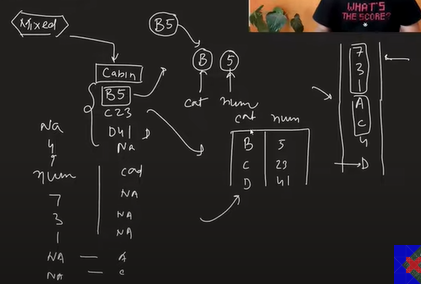

split a mixed variablr col. into two types of columns -> numerical col. and categoriccal col.

in the above pic one type of mixed variable is B5 wla coloumn second type is 7 3 1 A C wala column

#### There can be 2 types of Mixed Dat can be
> Numerical or Categorical sth hga
> Numerical or Categorical alag alag hga per 1 hi cloumn ma hga

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("titanic2.csv")

In [4]:
df.head() #number column means family members A means travelling alone

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


> here are the two types i wrote earlier

In [6]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [7]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

In [ ]:
df['Ticket'].unique()

#### visualzation

In [14]:
df['Cabin'].value_counts(dropna=False).sum()

np.int64(891)

In [ ]:
df['Cabin'].values

Text(0.5, 1.0, 'Passengers travelling with')

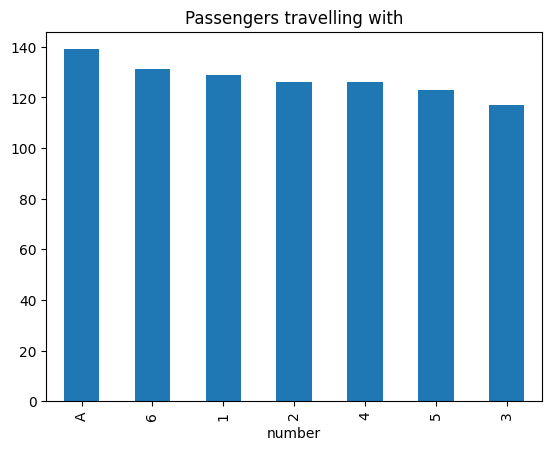

In [15]:
fig=df['number'].value_counts().plot.bar()
fig.set_title("Passengers travelling with")

>* Now we'll separate numbers and alphabets from 1st column

> pd.to_numeric():

>The main function that attempts to convert the input to numeric dtype
>Can convert strings, mixed types, or other compatible types to numbers

> Tells pandas what to do with values that can't be converted to numbers
>With 'coerce', invalid parsing will be set as NaN (Not a Number)

> Assuming 'coerce' fixes data problems:
It just hides them by converting to NaN
Always check how many values were coerced:

In [25]:
df['number_numerical']=pd.to_numeric(df['number'],errors='raise',downcast='integer')

ValueError: Unable to parse string "A" at position 4

In [26]:
df['number_numerical']=pd.to_numeric(df['number'],errors='ignore',downcast='integer')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17472\2311736784.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df['number_numerical']=pd.to_numeric(df['number'],errors='ignore',downcast='integer')


In [32]:
df['number_numerical']=pd.to_numeric(df['number'],errors='coerce',downcast='integer')

In [34]:
df['number_numerical']

0      5.0
1      3.0
2      6.0
3      3.0
4      NaN
      ... 
886    3.0
887    3.0
888    1.0
889    2.0
890    3.0
Name: number_numerical, Length: 891, dtype: float64

> **The Core Issue**
* When you specify downcast='integer' but get float64 instead, it typically means:
    * Your data contains decimal values - Even one float value prevents integer conversion\
    * You have NaN values - Missing values force float dtype in pandas\
    * Your numbers are too large - Exceed the maximum integer size for downcasting

In [37]:
print(f"Number of NaN values: {df['number_numerical'].isnull().sum()}")

Number of NaN values: 139


* Now its time for Cabin and Ticket number column
    * 2no ky 2 alag column bnyngy one for categore and second for number

In [39]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)')
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17472\3544118145.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)')


* > df['Cabin'].str.extract('(\d+)') can be understood as:

    * df['Cabin'] - Selects the 'Cabin' column from the DataFrame

    * .str - Accesses pandas string methods

    * .extract() - Method for extracting substrings using regex

    * '(\d+)' - The regular expression pattern

In [40]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN
1,C85,PC 17599,3,1,3.0,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN
3,C123,113803,3,1,3.0,123,C
4,NaN,373450,A,0,NaN,NaN,NaN


<Axes: xlabel='cabin_cat'>

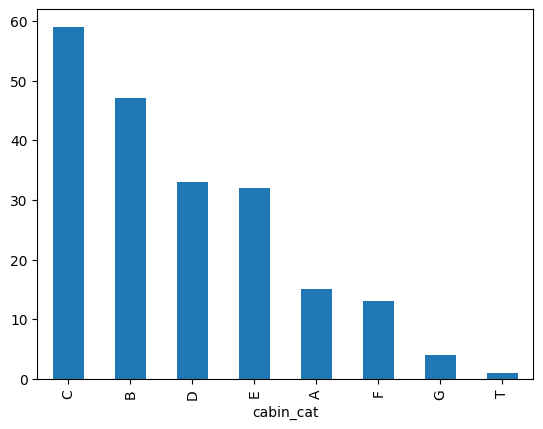

In [43]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [47]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')
# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])


In [48]:
df['ticket_cat'].unique()

array(['A/5', 'PC', 'STON/O2.', nan, 'PP', 'A/5.', 'C.A.', 'A./5.',
       'SC/Paris', 'S.C./A.4.', 'A/4.', 'CA', 'S.P.', 'S.O.C.', 'SO/C',
       'W./C.', 'SOTON/OQ', 'W.E.P.', 'STON/O', 'A4.', 'C', 'SOTON/O.Q.',
       'SC/PARIS', 'S.O.P.', 'A.5.', 'Fa', 'CA.', 'LINE', 'F.C.C.', 'W/C',
       'SW/PP', 'SCO/W', 'P/PP', 'SC', 'SC/AH', 'A/S', 'A/4', 'WE/P',
       'S.W./PP', 'S.O./P.P.', 'F.C.', 'SOTON/O2', 'S.C./PARIS',
       'C.A./SOTON'], dtype=object)